In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
import os
import random

In [2]:
# def transform(image):
#     grayScale = cv.cvtColor( image, cv.COLOR_RGB2GRAY )
#     kernel = cv.getStructuringElement(1,(17,17))
#     blackhat = cv.morphologyEx(grayScale, cv.MORPH_BLACKHAT, kernel)
#     ret,thresh2 = cv.threshold(blackhat,10,255,cv.THRESH_BINARY)
#     image = cv.inpaint(image,thresh2,1,cv.INPAINT_TELEA)
#     return image

In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomContrast(0.3),
])

root = './train'
buckets = {}
images = []
labels = []

h, w = 112, 112

for img_name in os.listdir(root):
    class_img = img_name.split('_')[0]
    if class_img == 'nv': continue
    img = cv.imread(os.path.join(root,img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (h, w))
    # img = transform(img)
    if class_img in buckets: buckets[class_img]+=1
    else: buckets[class_img] = 0
    images.append(img)
    labels.append(class_img)
    if class_img in ['df', 'bcc', 'akiec', 'vasc']:
        for _ in range(2):
            buckets[class_img] += 1
            augmented_img = data_augmentation(tf.expand_dims(img, 0))
            images.append(tf.squeeze(augmented_img, axis=0).numpy())
            labels.append(class_img)
    if class_img in ['df', 'vasc']:
        for _ in range(1):
            buckets[class_img] += 1
            augmented_img = data_augmentation(tf.expand_dims(img, 0))
            images.append(tf.squeeze(augmented_img, axis=0).numpy())
            labels.append(class_img)

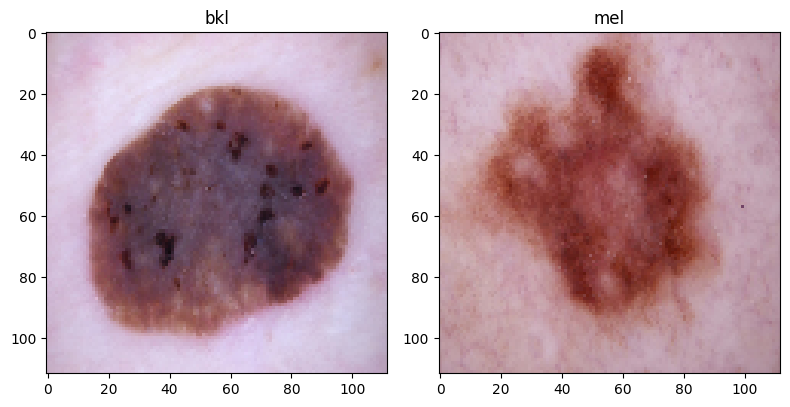

In [4]:
i = random.randint(0,len(images))
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(images[i])
plt.title(labels[i])
i = random.randint(0,len(images))
plt.subplot(1,2,2)
plt.imshow(images[i])
plt.title(labels[i])
plt.tight_layout()
plt.show()

In [5]:
print(buckets)

{'bkl': 1098, 'mel': 1112, 'df': 459, 'bcc': 1541, 'akiec': 980, 'vasc': 567}


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
images = np.array(images)/255.0
labels = np.array(labels)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, shuffle=True, random_state=42)

Text(0.5, 1.0, '1, test')

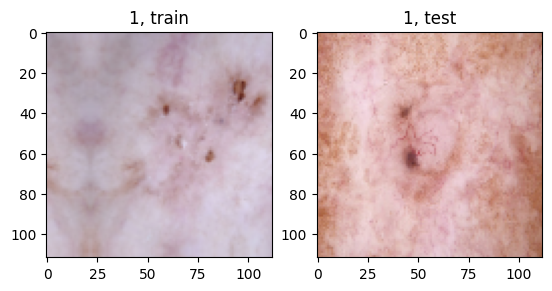

In [8]:
plt.subplot(1,2,1)
i = random.randint(0,len(X_train))
plt.imshow(X_train[i])
plt.title(f'{y_train[i]}, train')
i = random.randint(0,len(X_test))
plt.subplot(1,2,2)
plt.imshow(X_test[i])
plt.title(f'{y_test[i]}, test')

In [9]:
# bucks = {}
# train_dir = './train_dir'
# test_dir = './test_dir'
# for i in range(len(y_train)):
#     dx = le.inverse_transform([y_train[i]])[0]
#     if dx in bucks: bucks[dx]+=1
#     else: bucks[dx] = 0
#     img = cv.cvtColor(X_train[i], cv.COLOR_RGB2BGR)
#     cv.imwrite(os.path.join(train_dir, f'{dx}_{bucks[dx]}.jpg'), img)

# print('train: ',bucks)
# bucks = {}
# for i in range(len(y_test)):
#     dx = le.inverse_transform([y_test[i]])[0]
#     if dx in bucks: bucks[dx]+=1
#     else: bucks[dx] = 0
#     img = cv.cvtColor(X_test[i], cv.COLOR_RGB2BGR)
#     cv.imwrite(os.path.join(test_dir, f'{dx}_{bucks[dx]}.jpg'), img)
# print('test: ',bucks)

In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(h, w, 3))

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
callbacks = [ tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
             tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3),]


history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks)

Epoch 1/20
145/145 [==============================] - 99s 669ms/step - loss: 1.9330 - accuracy: 0.2124 - val_loss: 1.7027 - val_accuracy: 0.2810 - lr: 1.0000e-04
Epoch 2/20
145/145 [==============================] - 98s 677ms/step - loss: 1.8278 - accuracy: 0.2169 - val_loss: 1.7180 - val_accuracy: 0.2793 - lr: 1.0000e-04
Epoch 3/20
145/145 [==============================] - 95s 652ms/step - loss: 1.7866 - accuracy: 0.2358 - val_loss: 1.7199 - val_accuracy: 0.2923 - lr: 1.0000e-04
Epoch 4/20
145/145 [==============================] - 94s 649ms/step - loss: 1.7590 - accuracy: 0.2323 - val_loss: 1.7329 - val_accuracy: 0.2810 - lr: 1.0000e-04
Epoch 5/20
145/145 [==============================] - 104s 716ms/step - loss: 1.7559 - accuracy: 0.2440 - val_loss: 1.7383 - val_accuracy: 0.2862 - lr: 1.0000e-05
Epoch 6/20
145/145 [==============================] - 95s 656ms/step - loss: 1.7508 - accuracy: 0.2443 - val_loss: 1.7419 - val_accuracy: 0.2845 - lr: 1.0000e-05


In [12]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.284


37/37 [==============================] - 19s 498ms/step


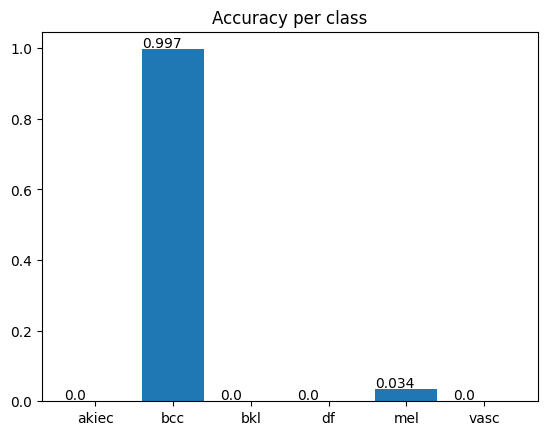

In [13]:
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_test_label = np.argmax(y_test, axis=1)
# make a bargraph of accuracy per class
from sklearn.metrics import accuracy_score
acc_per_class = []
for i in range(6):
    acc_per_class.append(accuracy_score(y_test_label[y_test_label==i], y_pred_label[y_test_label==i]))

bars  = plt.bar(le.classes_, acc_per_class)
plt.title('Accuracy per class')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .005, round(yval,3))
plt.show()
# plt.bar(le.classes_, acc_per_class)
# plt.title('Accuracy per class')
# plt.show()

Text(0, 0.5, 'Loss')

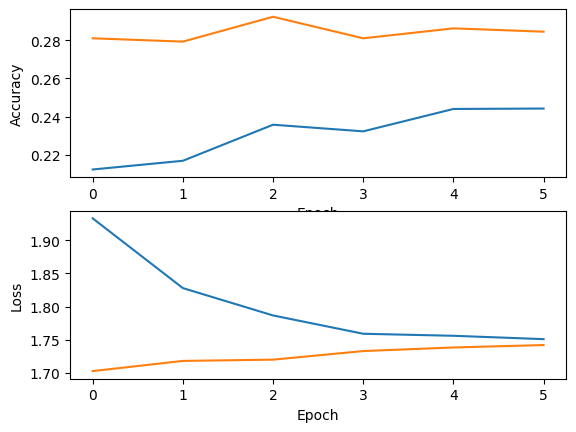

In [14]:
model.save('model_black_hat.keras')
plt.subplot(2,1,1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(2,1,2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')